# SoftROI-Boundary U-Net: project update

This notebook loads the completed experiment and visualizes its evidence. It does not retrain models. Select the project `.venv` Python environment.

The proposal combines a supervised soft ROI gate with boundary-conditioned, uncertainty-weighted residual refinement. The individual building blocks have prior work. This is a small-subset architecture pilot, not a verified state-of-the-art method.

In [1]:
from pathlib import Path
import os, json, csv
ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
results = json.loads(Path('runs/main/results.json').read_text())
print('Subset:', results['subset_summary'])
print('Training:', results['configuration']['epochs'], 'epochs; seeds', results['configuration']['seeds'])

Subset: {'train': {'patients': 48, 'slices': 398, 'class_counts': {'0': 104, '1': 137, '2': 157}}, 'val': {'patients': 12, 'slices': 117, 'class_counts': {'0': 38, '1': 39, '2': 40}}, 'test': {'patients': 15, 'slices': 129, 'class_counts': {'0': 41, '1': 45, '2': 43}}}
Training: 60 epochs; seeds [17, 29]


## Architecture

MRI encoder, a coarse tumor head, soft-gated skip connections, and a U-Net decoder. The full model adds a predicted boundary map and a residual correction multiplied by `u = 4p(1-p)`. All inference uses MRI intensities only. See `ARCHITECTURE.md` for the complete diagram.

In [2]:
from src.models import TumorNet
for variant in ['baseline', 'softroi', 'srb']:
    model = TumorNet(variant)
    print(variant, f'{sum(p.numel() for p in model.parameters()):,}', 'parameters')

baseline 488,100 parameters
softroi 488,229 parameters
srb 492,167 parameters


## Held-out results

Scores below average two independent training seeds. Patient Dice and IoU give each patient equal weight. The test set has 15 patients. The paper's metrics use a different protocol and are not directly comparable.

In [3]:
for name, info in results['aggregate'].items():
    m = info['means']
    print(f"{name:10s} Patient Dice {100*m['patient_dice']:.2f}%  Patient IoU {100*m['patient_iou']:.2f}%  Boundary F1 {100*m['slice_boundary_f1']:.2f}%")
print('Paired comparison:', results['srb_vs_baseline'])

baseline   Patient Dice 59.79%  Patient IoU 49.82%  Boundary F1 60.71%
softroi    Patient Dice 61.97%  Patient IoU 52.04%  Boundary F1 62.73%
srb        Patient Dice 63.17%  Patient IoU 53.76%  Boundary F1 65.79%
Paired comparison: {'patient_dice_delta': 0.03375816898711966, 'paired_patient_bootstrap_95_ci': [-0.0018456214777963092, 0.06735816860142578], 'n_patients': 15, 'patients_improved': 13, 'method': '10,000 paired patient bootstrap resamples, seeds averaged within patients; does not capture full training or split variability'}


## Learning curves and examples

Qualitative examples use seed 17 and the first held-out slice of each tumor class in the frozen manifest. The failure example is the largest SRB regression relative to the baseline for that seed.

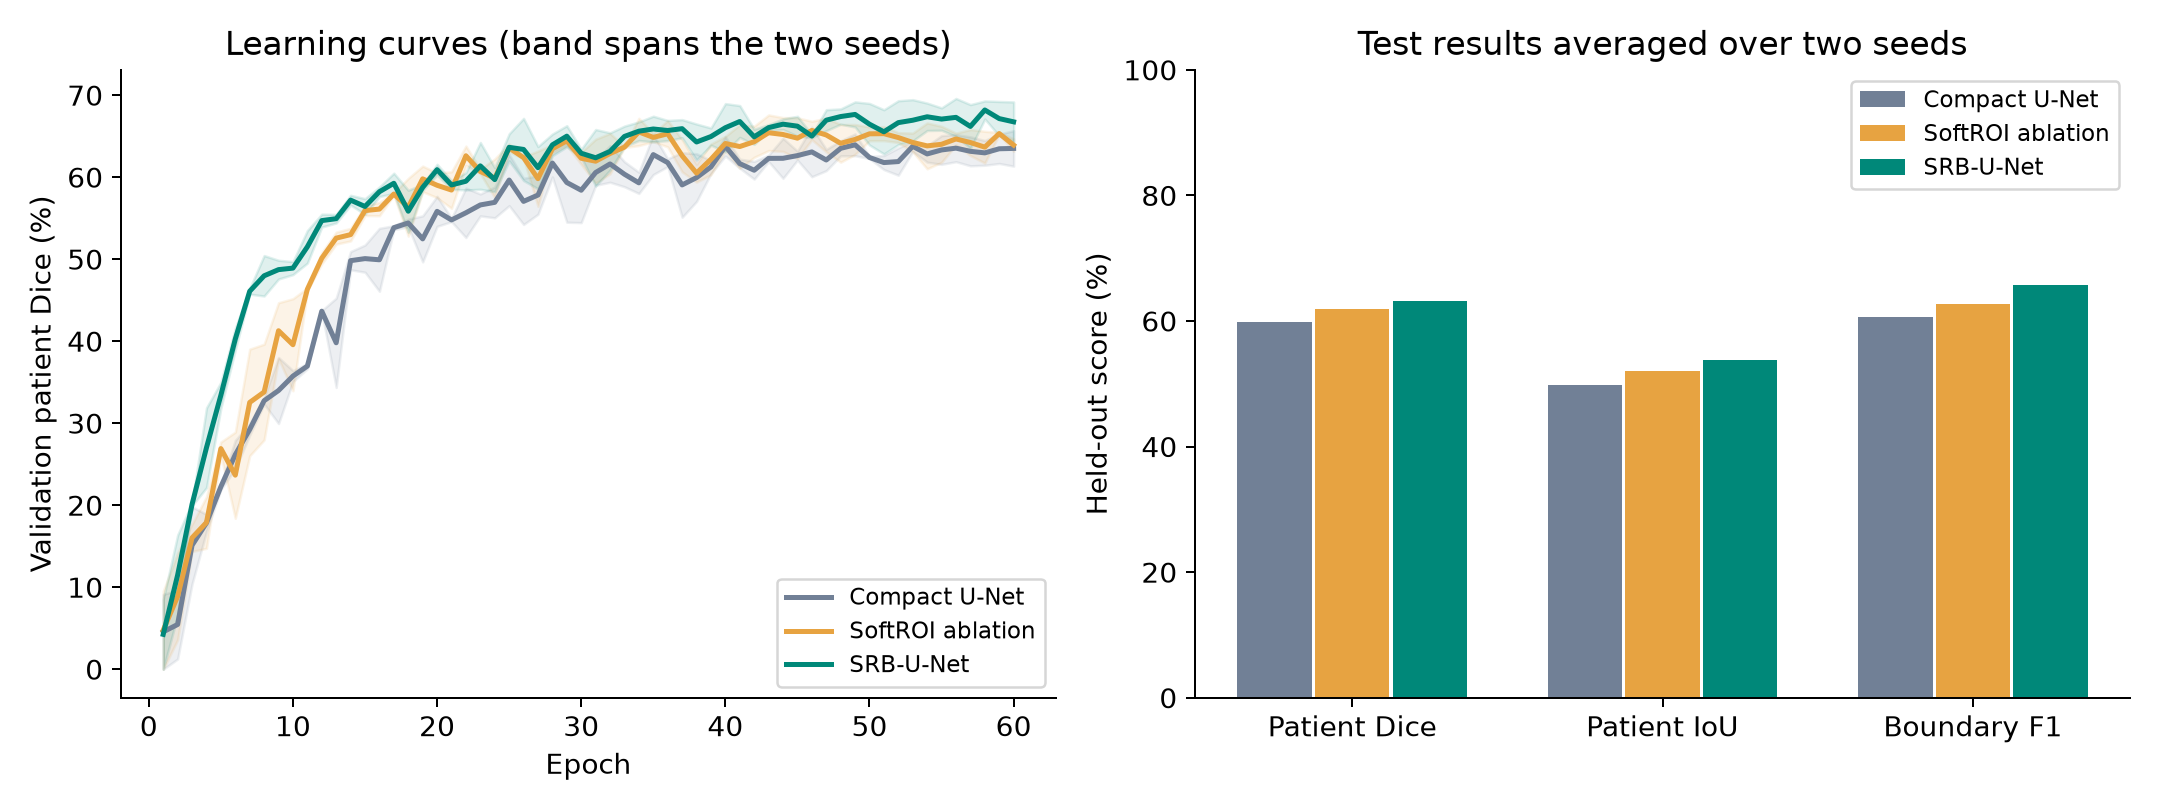

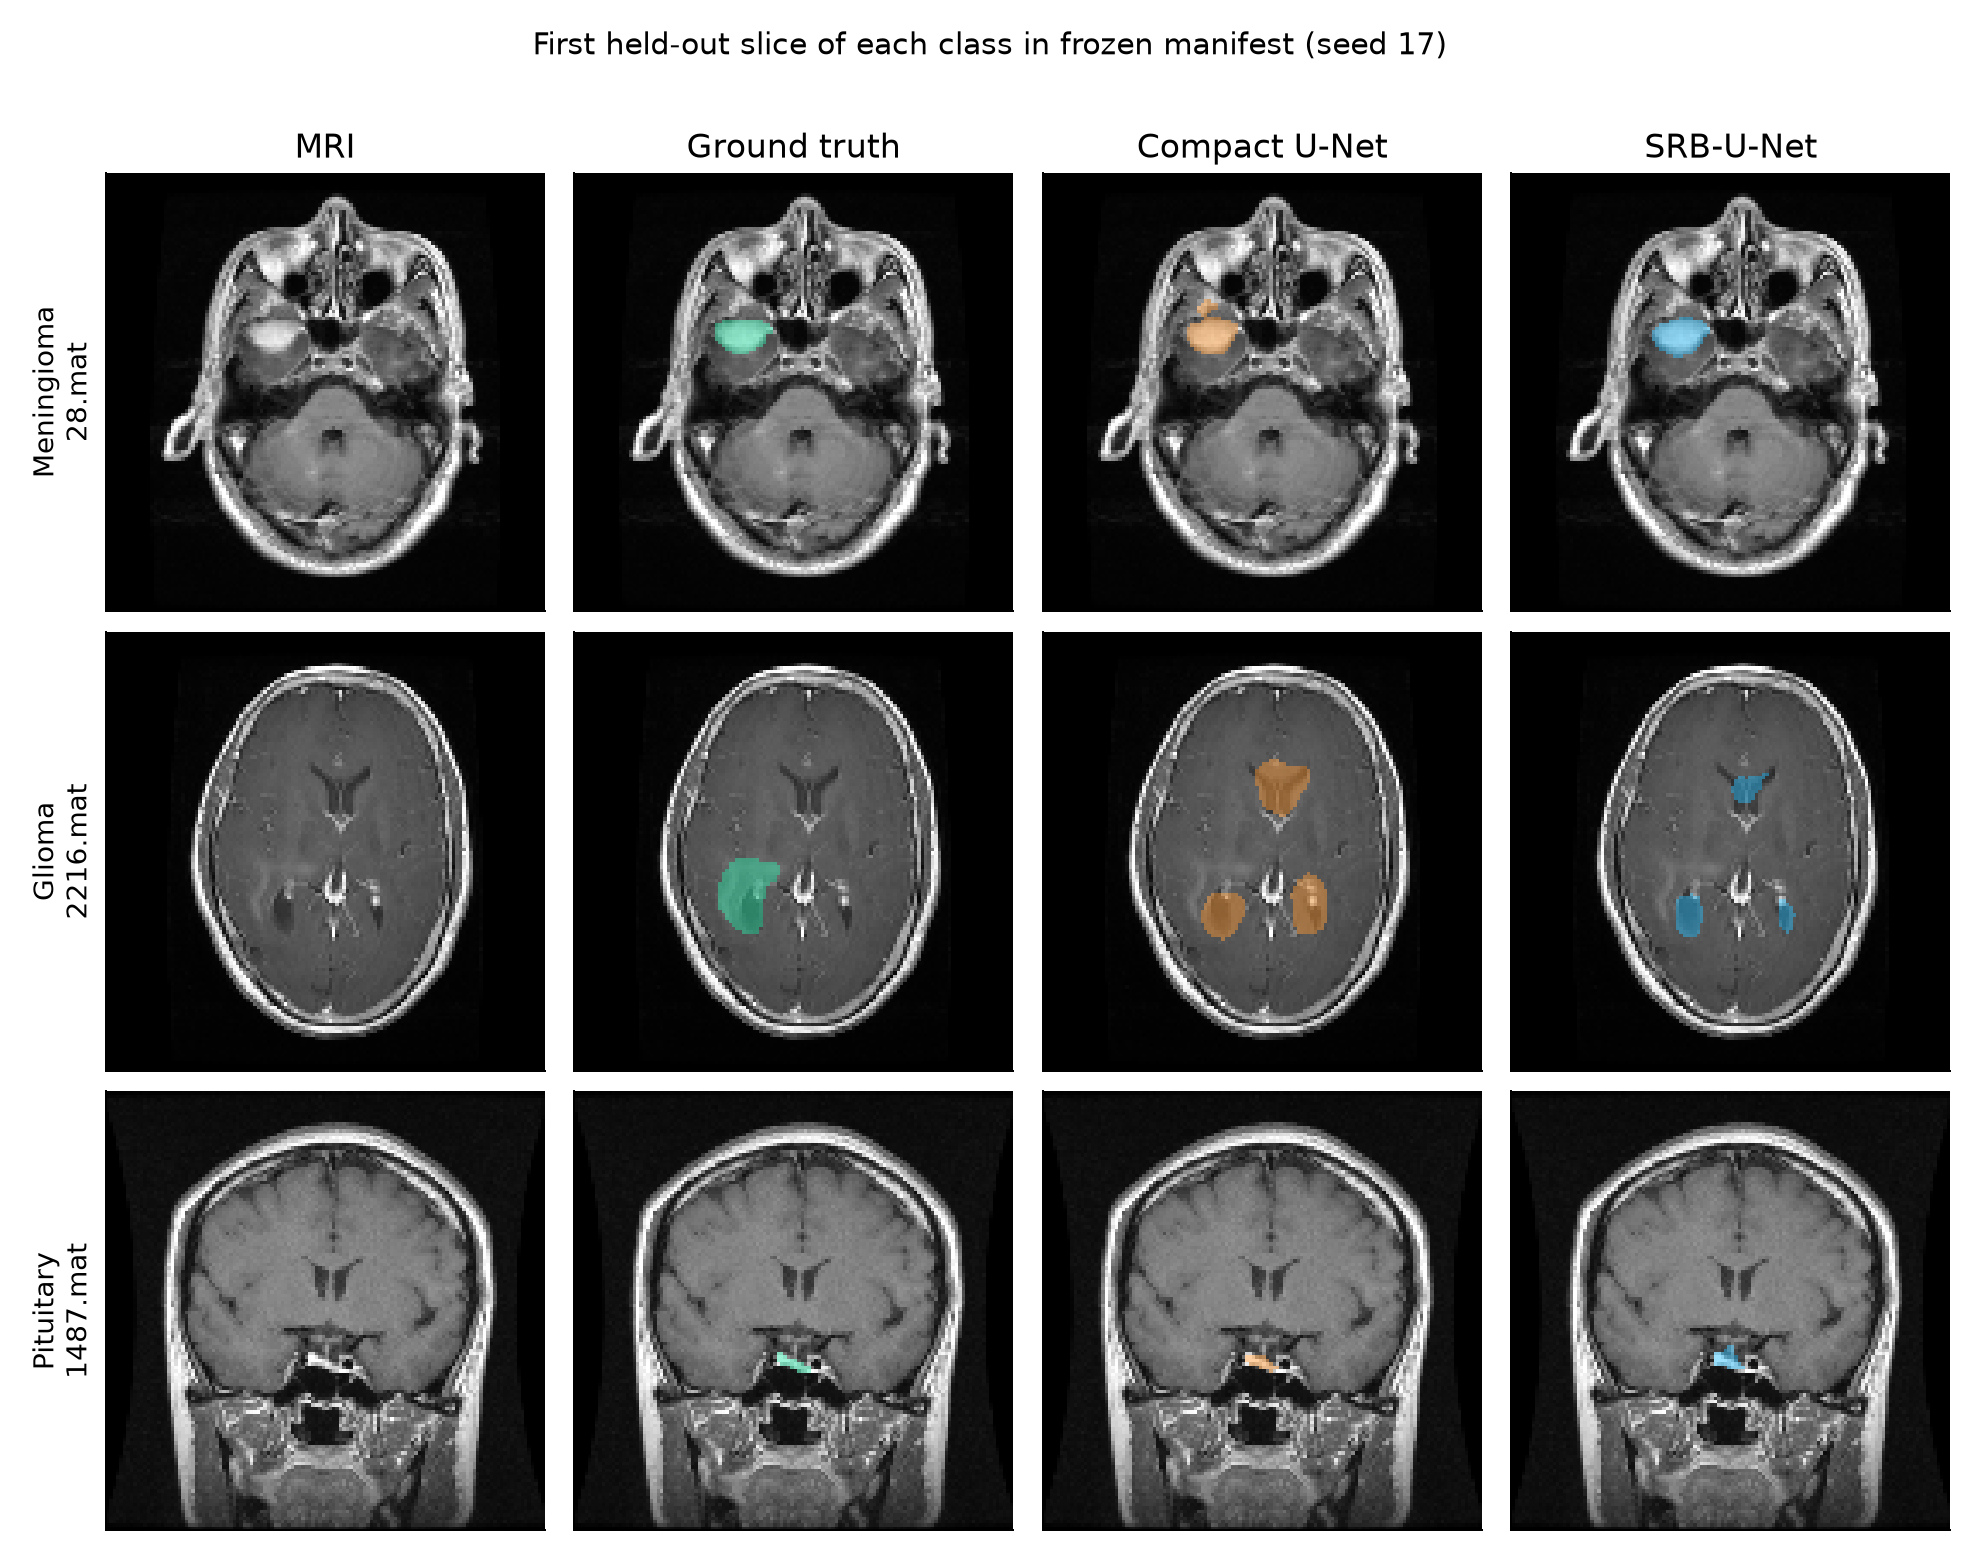

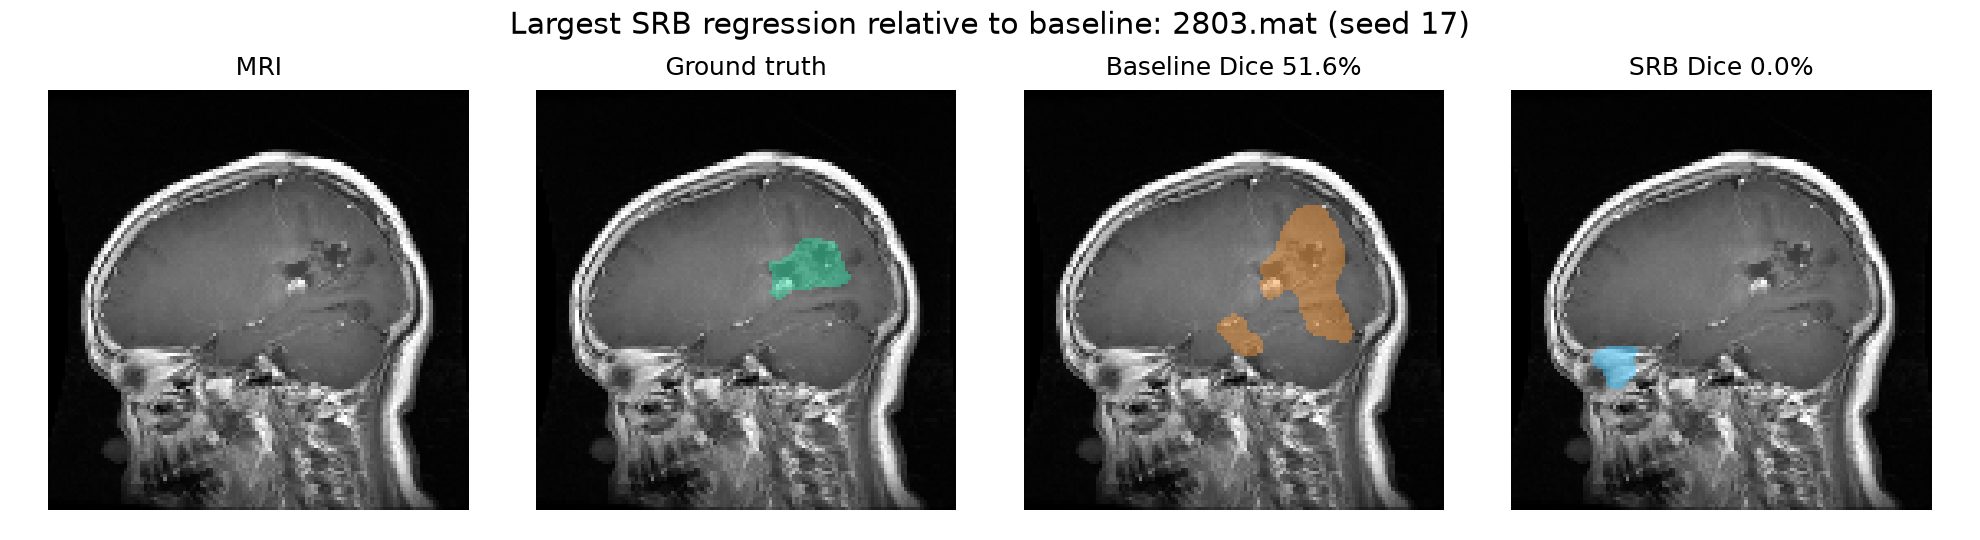

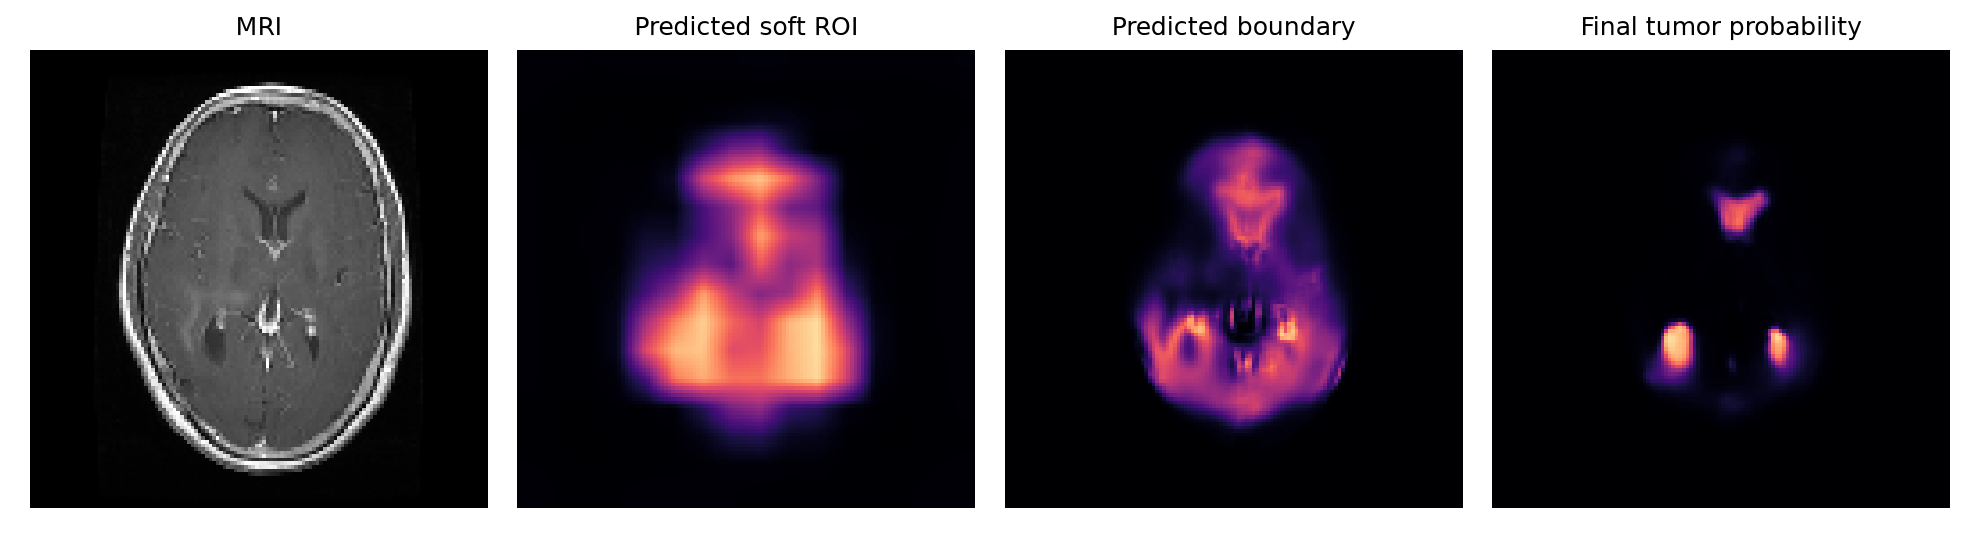

In [4]:
from IPython.display import display
from PIL import Image
for name in ['learning_and_results.png', 'qualitative_examples.png', 'failure_case.png', 'mechanism_maps.png']:
    display(Image.open(Path('output/figures') / name))

## Saved-model demo

Run MRI-only inference on the first frozen test slice. The output includes a segmentation overlay and tumor-type probabilities. Its bounding box is derived from the predicted mask, not from a separately trained object detector.

{
  "input": "data/mat/28.mat",
  "variant": "srb",
  "seed": 17,
  "predicted_class": "pituitary",
  "class_probabilities": {
    "meningioma": 0.4329986572265625,
    "glioma": 0.015920022502541542,
    "pituitary": 0.5510813593864441
  },
  "mask_derived_bbox_xyxy_exclusive": [
    165,
    169,
    232,
    215
  ],
  "notes": "Research demo trained on tumor-positive slices only. Bounding box comes from the segmentation mask, not an object detector. Full-resolution display uses interpolated 128x128 predictions."
}


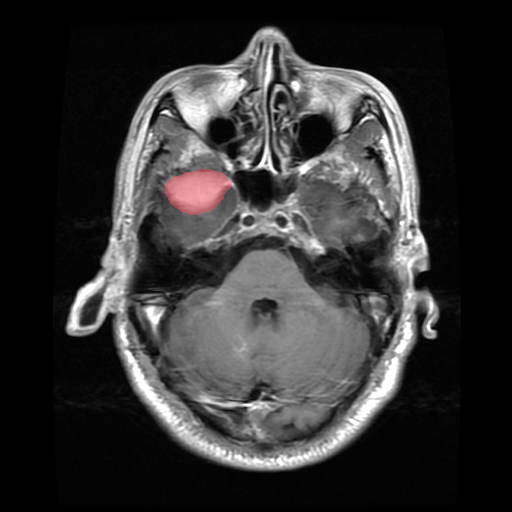

In [5]:
from src.predict import predict
manifest = json.loads(Path('data/processed/manifest.json').read_text())
example = next(r for r in manifest['records'] if r['split'] == 'test')
predict('runs/main/srb_seed17/checkpoints/best.pt', Path('data/mat')/example['file'], 'output/notebook_demo')
display(Image.open('output/notebook_demo/overlay.png'))

## Interpretation and next steps

Read the seed-specific numbers and confidence interval, including regressions. The ablation combines architecture changes and additional supervision. Next: more patient splits and seeds, finer ablation of each loss/module, higher-resolution training, and a faithful YOLOv5 + U-Net comparison. Healthy-versus-tumor screening needs normal MRI examples that this dataset does not contain.